In [1]:
import pandas as pd

# Cargar los 4 datasets de ingresos municipalidades
df_original   = pd.read_csv(
    'INGRESOS_HISTORICO_TOTAL_2012_2026.csv',
    encoding='latin-1',
    usecols=[
        'ANO_DOC', 'MES_DOC',
        'NIVEL_GOBIERNO', 'NIVEL_GOBIERNO_NOMBRE',
        'SEC_EJEC', 'EJECUTORA_NOMBRE',
        'DEPARTAMENTO_EJECUTORA', 'DEPARTAMENTO_EJECUTORA_NOMBRE',
        'PROVINCIA_EJECUTORA', 'PROVINCIA_EJECUTORA_NOMBRE',
        'DISTRITO_EJECUTORA', 'DISTRITO_EJECUTORA_NOMBRE',
        'FUENTE_FINANCIAMIENTO', 'FUENTE_FINANCIAMIENTO_NOMBRE',
        'RUBRO', 'RUBRO_NOMBRE',
        'GENERICA', 'GENERICA_NOMBRE',
        'SUBGENERICA', 'SUBGENERICA_NOMBRE',
        'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO',
        'ARCHIVO_ORIGEN'
    ]
)
df_original = df_original[df_original['NIVEL_GOBIERNO'] == 'M']

df_simple     = pd.read_parquet('ingresos_silver_simple.parquet')
df_intermedio = pd.read_parquet('ingresos_silver_intermedio.parquet')
df_avanzado   = pd.read_parquet('ingresos_silver_avanzado.parquet')

datasets = {
    "Original":   df_original,
    "Simple":     df_simple,
    "Intermedio": df_intermedio,
    "Avanzado":   df_avanzado
}

print("✅ Datasets cargados correctamente")
for nombre, df in datasets.items():
    print(f"   {nombre:<12}: {len(df):,} registros, {len(df.columns)} columnas")

C:\Users\Jean Carlos\AppData\Local\Temp\ipykernel_7864\4084384371.py:4: DtypeWarning: Columns (0: DISTRITO_EJECUTORA_NOMBRE, 1: FUENTE_FINANCIAMIENTO_NOMBRE, 2: RUBRO_NOMBRE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original   = pd.read_csv(


✅ Datasets cargados correctamente
   Original    : 8,880,692 registros, 24 columnas
   Simple      : 8,804,480 registros, 38 columnas
   Intermedio  : 2,852,681 registros, 29 columnas
   Avanzado    : 2,181,543 registros, 27 columnas


In [2]:
# Eliminar columnas temporales generadas durante la limpieza
# que no forman parte del Silver definitivo
columnas_temp = ['NIVEL_NOMBRE_ESPERADO', 'ANO_ORIGEN', 'RUBRO_VALIDO',
                 'MONTO_PIA_NUMERICO', 'MONTO_PIM_NUMERICO',
                 'MONTO_RECAUDADO_NUMERICO']

for nombre, df_temp in datasets.items():
    for col in columnas_temp:
        if col in df_temp.columns:
            df_temp.drop(columns=[col], inplace=True)

print("✅ Columnas temporales eliminadas")

✅ Columnas temporales eliminadas


In [3]:
import numpy as np

# Clave de negocio para detectar duplicados en datos SIAF
cols_duplicados = [
    'ANO_DOC', 'MES_DOC', 'SEC_EJEC',
    'RUBRO', 'FUENTE_FINANCIAMIENTO',
    'GENERICA', 'SUBGENERICA'
]

def get_quality_metrics(df):
    existing_cols = [col for col in cols_duplicados if col in df.columns]

    # Nulos en columnas críticas
    columnas_criticas = [
        'NIVEL_GOBIERNO', 'EJECUTORA_NOMBRE',
        'DEPARTAMENTO_EJECUTORA_NOMBRE', 'RUBRO_NOMBRE',
        'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
    ]
    cols_criticas_presentes = [c for c in columnas_criticas if c in df.columns]

    # Montos negativos
    pia_neg = (df['MONTO_PIA'] < 0).sum()       if 'MONTO_PIA'       in df.columns else 0
    pim_neg = (df['MONTO_PIM'] < 0).sum()       if 'MONTO_PIM'       in df.columns else 0
    rec_neg = (df['MONTO_RECAUDADO'] < 0).sum() if 'MONTO_RECAUDADO' in df.columns else 0

    return {
        "registros":        len(df),
        "nulos_criticos":   df[cols_criticas_presentes].isnull().sum().sum(),
        "duplicados":       df.duplicated(subset=existing_cols).sum() if existing_cols else 0,
        "pia_negativos":    pia_neg,
        "pim_negativos":    pim_neg,
        "recaudado_negativos": rec_neg,
        "montos_negativos": pia_neg + pim_neg + rec_neg
    }

In [4]:
base_size  = len(df_original)
comparison = []

for nombre, df_temp in datasets.items():
    metrics = get_quality_metrics(df_temp)

    comparison.append({
        "Dataset":              nombre,
        "Registros":            metrics["registros"],
        "Pérdida (%)":          round(
            (base_size - metrics["registros"]) / base_size * 100, 2
        ),
        "Nulos críticos":       metrics["nulos_criticos"],
        "Duplicados":           metrics["duplicados"],
        "MONTO_PIA neg.":       metrics["pia_negativos"],
        "MONTO_PIM neg.":       metrics["pim_negativos"],
        "MONTO_RECAUDADO neg.": metrics["recaudado_negativos"],
        "Total montos neg.":    metrics["montos_negativos"]
    })

comparison_df = pd.DataFrame(comparison)

print("=" * 70)
print("   COMPARATIVA DE CALIDAD — Ingresos Municipalidades SIAF 2012-2026")
print("=" * 70)
display(comparison_df)

   COMPARATIVA DE CALIDAD — Ingresos Municipalidades SIAF 2012-2026


,Dataset,Registros,Pérdida (%),Nulos críticos,Duplicados,MONTO_PIA neg.,MONTO_PIM neg.,MONTO_RECAUDADO neg.,Total montos neg.
0,Original,8880692,0.00,0,6028011,0,13503,62726,76229
1,Simple,8804480,0.86,0,5988285,0,0,0,0
2,Intermedio,2852681,67.88,0,0,0,0,0,0
3,Avanzado,2181543,75.43,0,0,0,0,0,0


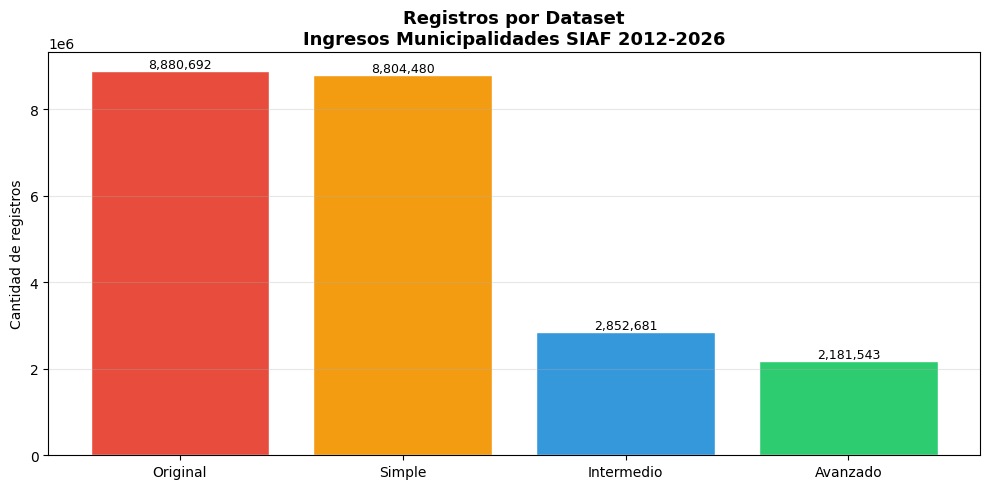

In [5]:
import matplotlib.pyplot as plt

# Gráfico 1: Registros por dataset
plt.figure(figsize=(10, 5))
colores = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = plt.bar(comparison_df["Dataset"], comparison_df["Registros"],
               color=colores, edgecolor='white')
plt.title(
    'Registros por Dataset\nIngresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel("Cantidad de registros")
plt.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, comparison_df["Registros"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{v:,}', ha='center', va='bottom', fontsize=9
    )
plt.tight_layout()
plt.show()

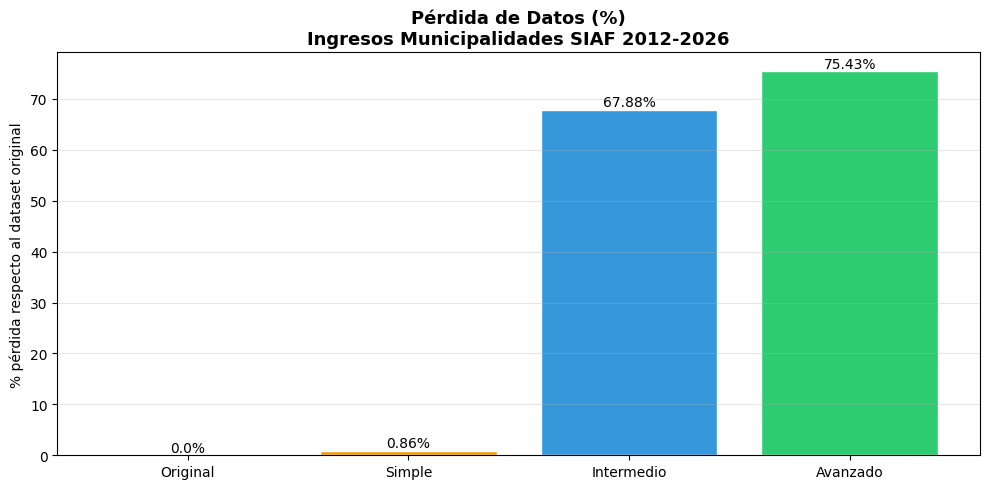

In [6]:
# Gráfico 2: Pérdida de datos por dataset
plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_df["Dataset"], comparison_df["Pérdida (%)"],
               color=colores, edgecolor='white')
plt.title(
    'Pérdida de Datos (%)\nIngresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel("% pérdida respecto al dataset original")
plt.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, comparison_df["Pérdida (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{v}%', ha='center', va='bottom', fontsize=10
    )
plt.tight_layout()
plt.show()

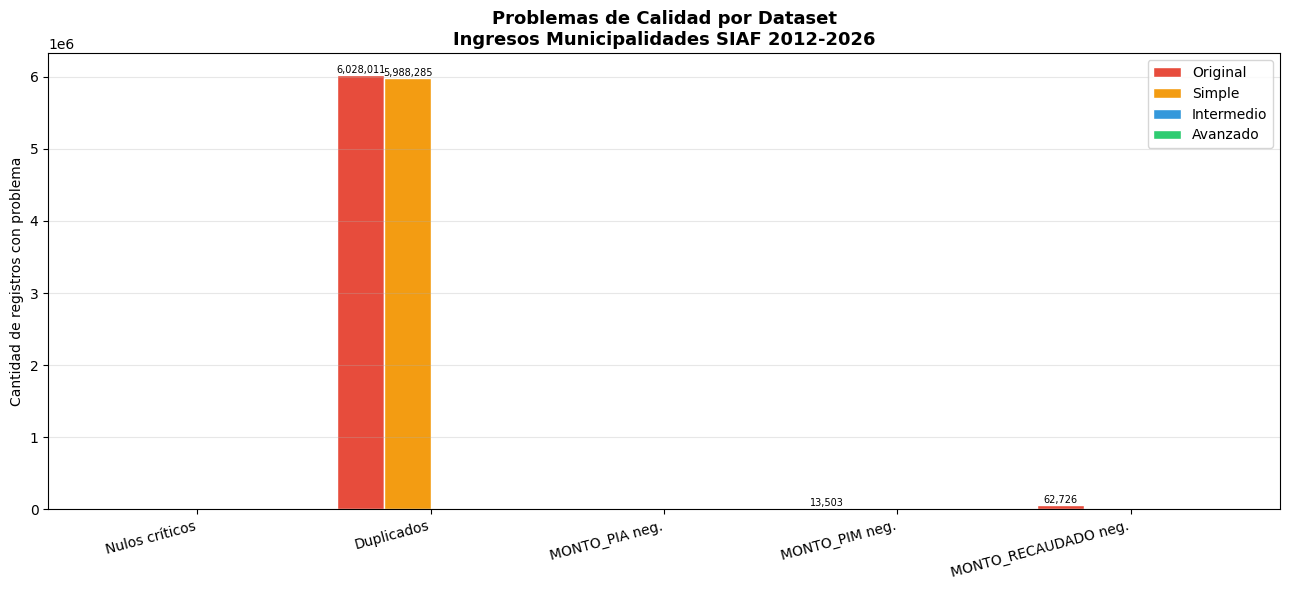

In [7]:
# Gráfico 3: Problemas de calidad por dataset
problemas_cols = [
    "Nulos críticos",
    "Duplicados",
    "MONTO_PIA neg.",
    "MONTO_PIM neg.",
    "MONTO_RECAUDADO neg."
]

x     = np.arange(len(problemas_cols))
width = 0.2

plt.figure(figsize=(13, 6))

for i, (nombre, df_temp) in enumerate(datasets.items()):
    metrics = get_quality_metrics(df_temp)
    values  = [
        metrics["nulos_criticos"],
        metrics["duplicados"],
        metrics["pia_negativos"],
        metrics["pim_negativos"],
        metrics["recaudado_negativos"]
    ]
    bars = plt.bar(x + i * width, values, width,
                   label=nombre, color=colores[i],
                   edgecolor='white')
    for bar, v in zip(bars, values):
        if v > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{v:,}', ha='center', va='bottom', fontsize=7
            )

plt.xticks(x + width * 1.5, problemas_cols, rotation=15, ha='right')
plt.title(
    'Problemas de Calidad por Dataset\nIngresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel("Cantidad de registros con problema")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

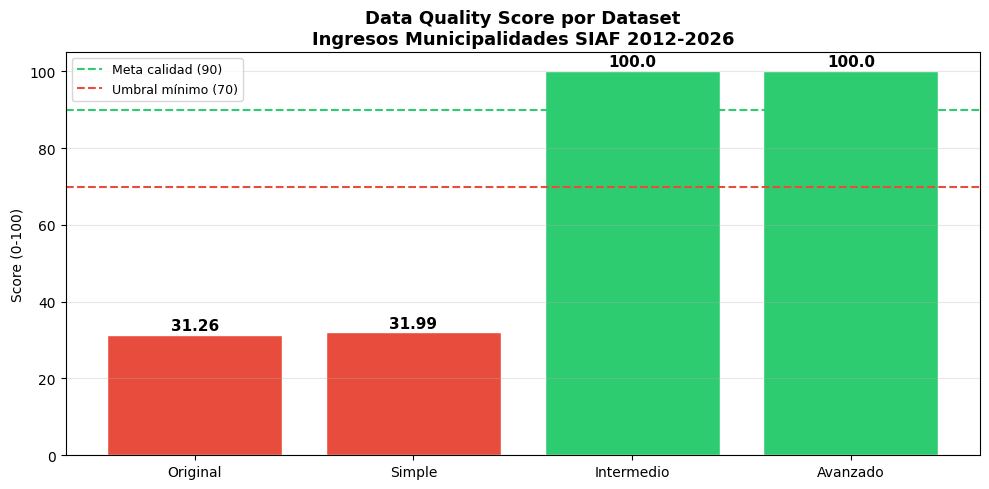


📊 Quality Scores:
   Original    :  31.26 — 🔴 BAJO
   Simple      :  31.99 — 🔴 BAJO
   Intermedio  :  100.0 — 🟢 BUENO
   Avanzado    :  100.0 — 🟢 BUENO


In [8]:
def quality_score(metrics, total_rows):
    issues = (
        metrics["nulos_criticos"]       +
        metrics["duplicados"]           +
        metrics["pia_negativos"]        +
        metrics["pim_negativos"]        +
        metrics["recaudado_negativos"]
    )
    score = max(0, 100 - (issues / total_rows * 100)) if total_rows > 0 else 0
    return round(score, 2)


scores = []

for nombre, df_temp in datasets.items():
    m     = get_quality_metrics(df_temp)
    score = quality_score(m, m["registros"])
    scores.append(score)

colores_score = [
    '#e74c3c' if s < 70 else '#f39c12' if s < 90 else '#2ecc71'
    for s in scores
]

plt.figure(figsize=(10, 5))
bars = plt.bar(datasets.keys(), scores,
               color=colores_score, edgecolor='white')
plt.axhline(y=90, color='#2ecc71', linestyle='--',
            linewidth=1.5, label='Meta calidad (90)')
plt.axhline(y=70, color='#e74c3c', linestyle='--',
            linewidth=1.5, label='Umbral mínimo (70)')
plt.title(
    'Data Quality Score por Dataset\nIngresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel("Score (0-100)")
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=9)
for bar, v in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{v}', ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
plt.tight_layout()
plt.show()

print("\n📊 Quality Scores:")
for nombre, score in zip(datasets.keys(), scores):
    estado = '🟢 BUENO' if score >= 90 else '🟡 REGULAR' if score >= 70 else '🔴 BAJO'
    print(f"   {nombre:<12}: {score:>6} — {estado}")